In [1]:
# Beskrivande analys
# Räkna ut medel, median, min och max för: age, weight, height, systolic_bp, cholesterol.

import pandas as pd
import numpy as np

df = pd.read_csv("Data\health_study_dataset.csv")

#df.info() # all columns seem to be in the correct data type
#Checking the data quality before starting the analyze
#print(df.isna().sum()) # there are no empty cells
#print("Duplicates :", df.duplicated().sum()) # there are no duplicated rows

#df.head()

def statistics (name_array):  #Function to calculate the average, median, min and max
    mean = np.mean(name_array)
    median = np.median(name_array)
    min = np.min(name_array)
    max = np.max(name_array)

    print(f"The average is {mean:.2f}")
    print(f"The median is {median:.2f}")
    print(f"The minimum is {min:.2f}")
    print(f"The maximum is {max:.2f}")
    print()


age = df["age"].to_numpy()
print("In column \"age\":")
statistics(age)

height = df["height"].to_numpy()
print("In column \"height\":")
statistics(height)

weight = df["weight"].to_numpy()
print("In column \"weight\":")
statistics(weight)

systolic_bp = df["systolic_bp"].to_numpy()
print("In column \"systolic_bp\":")
statistics(systolic_bp)

cholesterol = df["cholesterol"].to_numpy()
print("In column \"cholesterol\":")
statistics(cholesterol)


#df.describe() # checking with the data statistics if the values we are caluculating are correct


In column "age":
The average is 49.43
The median is 50.00
The minimum is 18.00
The maximum is 90.00

In column "height":
The average is 171.85
The median is 171.35
The minimum is 144.40
The maximum is 200.40

In column "weight":
The average is 73.41
The median is 73.20
The minimum is 33.70
The maximum is 114.40

In column "systolic_bp":
The average is 149.18
The median is 149.40
The minimum is 106.80
The maximum is 185.90

In column "cholesterol":
The average is 4.93
The median is 4.97
The minimum is 2.50
The maximum is 7.88



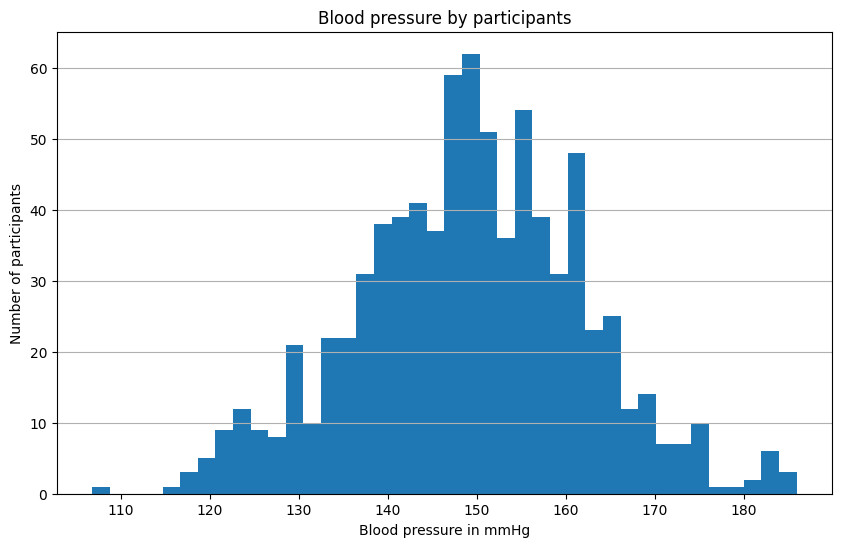

In [2]:
#Skapa minst 3 olika grafer (t.ex. histogram över blodtryck, boxplot över vikt per kön, stapeldiagram över andelen rökare).

# histogram över blodtryck

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (10,6))
ax.hist(df["systolic_bp"],bins =40)
ax.set_xlabel("Blood pressure in mmHg")
ax.set_ylabel("Number of participants")
ax.grid(True, axis = "y")
ax.set_title("Blood pressure by participants")
plt.tight_layout
plt.show()


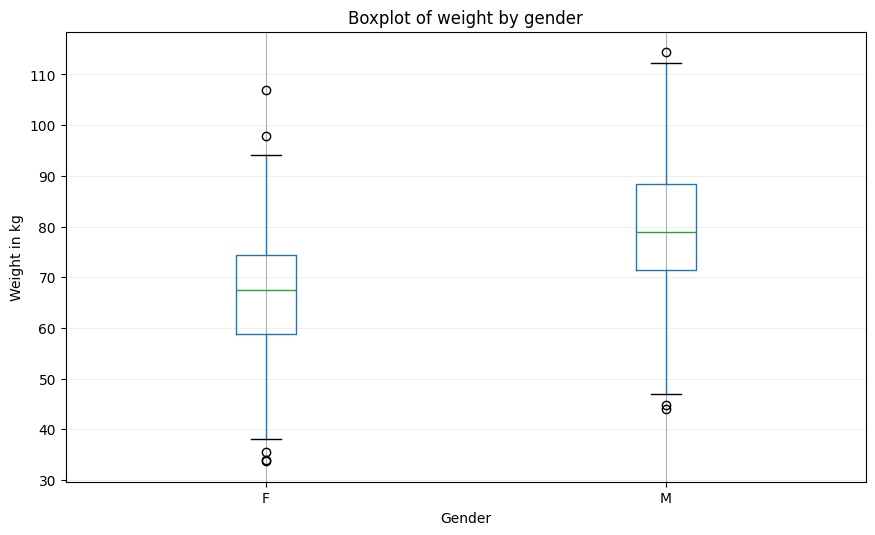

In [3]:
#boxplot över vikt per kön

fig, ax = plt.subplots(figsize = (10,6))
df.boxplot(column = "weight", by = "sex",ax=ax)
ax.set_xlabel("Gender")
ax.set_ylabel("Weight in kg")
ax.grid(True, alpha=0.2 ,axis = "y")
ax.set_title("Boxplot of weight by gender")
plt.suptitle("")
plt.tight_layout
plt.show()

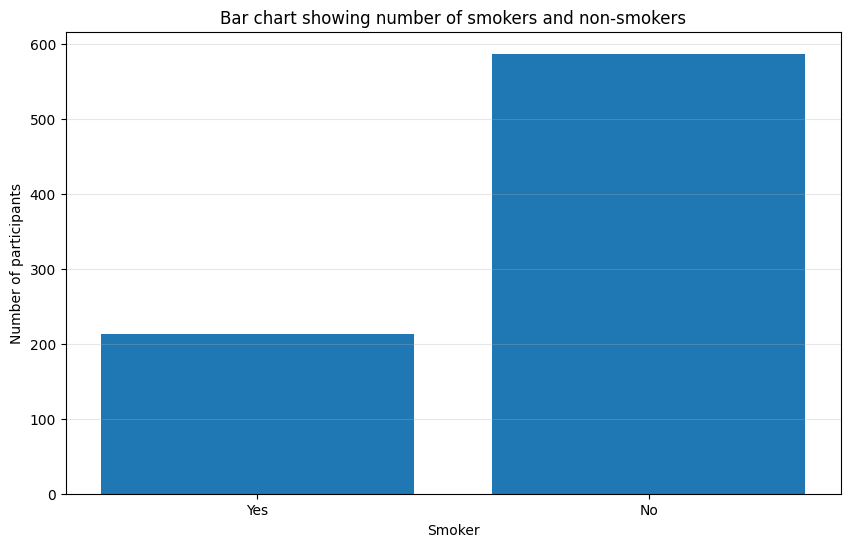

In [4]:
#stapeldiagram över andelen rökare

smoker_df = df[df['smoker'] != 'No']
non_smoker_df = df[df['smoker'] == 'No']
len(smoker_df)
len(non_smoker_df)

fig, ax = plt.subplots(figsize = (10,6))
ax.bar(['Yes', 'No'], [len(smoker_df), len(non_smoker_df)])
ax.set_xlabel("Smoker")
ax.set_ylabel("Number of participants")
ax.grid(True, alpha = 0.3, axis = "y")
ax.set_title("Bar chart showing number of smokers and non-smokers")
plt.tight_layout
plt.show()

In [5]:
#Simulering kopplad till caset 
#Beräkna andelen personer i datasetet som har sjukdomen

sick_df = df[df['disease'] != 0]
print(f"~{len(sick_df)/len(df):.2f}% of the participants declare having a disease")

~0.06% of the participants declare having a disease


In [6]:
#Använd numpy för att simulera 1000 slumpade personer med samma sannolikhet för sjukdom
np.random.seed(42)
n = 1_000
diseases = np.random.choice(df["disease"],size= n,replace = True)

mean_diseases = np.mean(diseases)
mean_sick_df= np.mean(df["disease"])

#Jämför den simulerade andelen med den verkliga andelen i datasetet.
print(f"The average of sick participants in the simulated data base of 1 000 is {mean_diseases:.3f}%\nThe average of sick participants in the original data base is {mean_sick_df:.3f}%")
#print(diseases)

The average of sick participants in the simulated data base of 1 000 is 0.063%
The average of sick participants in the original data base is 0.059%


148.2982573602501 149.02954263974993 148.6639 13.191244390720502 5000


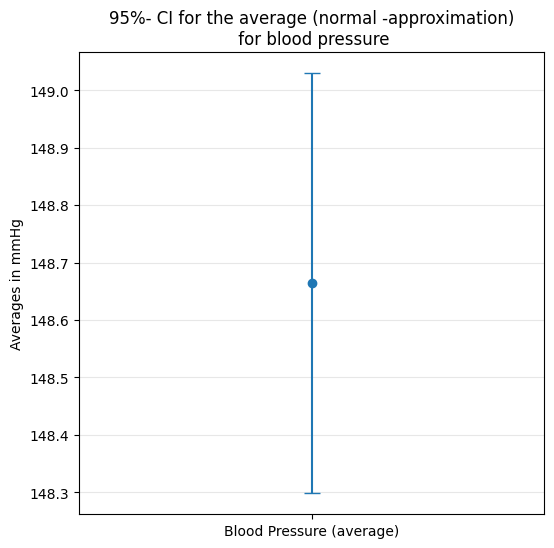

In [18]:
# Beräkna ett konfidensintervall för medelvärdet av systolic_bp (t.ex. med normalapproximation eller bootstrap, som vi gått igenom på kursen).

#med normalapproximation
from math import sqrt
np.random.seed(42)

def ci_mean_normal (x, confidence= 0.95):
    x = np.asarray(x, dtype = float)
    mean_x = float(np.mean(x))
    s = float(np.std(x,ddof = 1))
    n= len(x)
    z_critical = 1.96
    half_width = z_critical * s  / sqrt (n)
    lo, hi = mean_x - half_width, mean_x + half_width
    return lo, hi, mean_x, s, n

x = np.random.choice(df["systolic_bp"], size = 5000, replace = True)

nlo, nhi, nmean_x, ns, nn = ci_mean_normal(x)

print(nlo, nhi, nmean_x, ns, nn)

fig, ax = plt.subplots(figsize = (6,6))
ax.errorbar([0],[nmean_x],yerr=[[nmean_x - nlo],[nhi - nmean_x]],fmt = "o", capsize = 6)
ax.set_title("95%- CI for the average (normal -approximation)\n for blood pressure")
ax.grid(True, axis = "y", alpha=0.3)
ax.set_xticks([0])
ax.set_ylabel("Averages in mmHg")
ax.set_xticklabels(["Blood Pressure (average)"])
plt.show()

In [8]:
# med bootstrap

def ci_mean_bootstrap(x,B= 5_000,confidence=0.95):
    x = np.asarray(x, dtype = float)
    n= len(x)
    boot_means = np.empty(B)
    for b in range (B):
        boot_sample=np.random.choice(x,size=n, replace= True)
        boot_means[b] = np.mean(boot_sample)
    alpha = (1 - confidence) / 2
    lo, hi = np.percentile(boot_means, [100 * alpha, 100 * (1 - alpha)])
    return float(lo), float(hi), float(np.mean(x))


np.random.seed(42)

blo, bhi, bmean = ci_mean_bootstrap(df["systolic_bp"], 5000)

print(blo, bhi, bmean)


148.31424687499998 150.08714375 149.178625


In [9]:
print(f"Using the normal approximation method:\nthe 95% confidence intervall for the average of the blood pressure is {nlo:.3f} -{nhi:.3f} mmHg. ")
print()
print(f"Using the bootstrap method:\nthe 95% confidence intervall for the average of the blood pressure is {blo:.3f} -{bhi:.3f} mmHg. ")
print()
print("Please note that the bootstrap method gives us a bigger confidence intervall and is less precise than the normal approximation method.\nThis is due to the size of the simulated sample being quite large (5.000). ")

Using the normal approximation method:
the 95% confidence intervall for the average of the blood pressure is 148.298 -149.030 mmHg. 

Using the bootstrap method:
the 95% confidence intervall for the average of the blood pressure is 148.314 -150.087 mmHg. 

Please note that the bootstrap method gives us a bigger confidence intervall and is less precise than the normal approximation method.
This is due to the size of the simulated sample being quite large (5.000). 


In [12]:
#Hypotesprövning
#Testa hypotesen: ”Rökare har högre medel-blodtryck än icke-rökare.”
#Använd en av metoderna vi gått igenom (t.ex. bootstrap eller enkel t-test-funktion).
#Förklara kort resultatet i en markdown-ruta.

df.head()
from scipy import stats

A = df.loc[df.smoker == "Yes", "systolic_bp"].values
#print(A, len(A)) # checking if the formula works and the length of both groups are covering all participants accordingly

B = df.loc[df.smoker == "No", "systolic_bp"].values
#print(B, len(B))

mu_A = np.mean(A)
mu_B = np.mean(B)
true_diff = mu_A - mu_B

#bootstrap method
np.random.seed(42)
n_boot = 5_000
boot_diff = np.empty(n_boot)
for b in range (n_boot):
    boot_A = np.random.choice(A, size = len(A), replace = True)
    boot_B = np.random.choice(B, size = len(B), replace = True)
    boot_diff[b] = np.mean(boot_A) - np.mean(boot_B)

p_boot = np.mean(np.abs(boot_diff) >= np.abs(true_diff))

cilow, cihigh = np.percentile(boot_diff, [2.5, 97.5])
print(f"Bootstrap method: p-value = {p_boot:.4f}, true difference in means = {true_diff:.3f}")
print(f"95% CI for the difference in means: {cilow:.3f} to {cihigh:.3f}")
print("""
We reject the null hypothesis since the p-value is higher than our significance limit of 0.05.
This means that there is a no statistical evidence of a significant difference in blood pressure between smokers and non-smokers.
      """)

Bootstrap method: p-value = 0.6854, true difference in means = 0.472
95% CI for the difference in means: -1.636 to 2.465

We reject the null hypothesis since the p-value is higher than our significance limit of 0.05.
This means that there is a no statistical evidence of a significant difference in blood pressure between smokers and non-smokers.
      


In [11]:
#Gör en simulering för att undersöka hur säkert ditt hypotes­test är (t.ex. hur ofta testet hittar en skillnad när den finns → power).

import statsmodels.stats.power as power_analysis

A = df.loc[df.smoker == "Yes", "systolic_bp"].values
B = df.loc[df.smoker == "No", "systolic_bp"].values

mu_A = np.mean(A)
mu_B = np.mean(B)

sd_pooled = np.sqrt(((len(A) - 1) * np.var(A, ddof=1) + (len(B) - 1) * np.var(B, ddof=1)) / (len(A) + len(B) - 2))

#print(mu_A, mu_B, sd_pooled) # Checking the calculated values

d = (mu_A - mu_B) / sd_pooled
print(f"Cohen's d effect size: {d:.3f}")
n_per_group = min(len(A), len(B))
print(f"Sample size per group: {n_per_group}")

power_analysis = power_analysis.TTestIndPower()
power_t = power_analysis.solve_power(effect_size=d, nobs1=n_per_group, alpha=0.05, ratio=1.0, alternative='larger')
print(f"Calculated power of the test: {power_t:.3f}")

n_needed = power_analysis.solve_power(effect_size=d, power=0.8, alpha=0.05, ratio=1.0, alternative='larger')
print(f"Required sample size per group for 80% power: {n_needed:.0f}")

print( f"""
The observed effect size (Cohen's d = {power_t:.3f}) is extremely small.
With a sample size of {n_per_group} per group, the statistical power is only {power_t*100:.1f}%, indicating a {100 - (power_t * 100):.1f}% chance of failing to detect the effect.
To achieve 80% power for such a small effect, approximately {n_needed:.0f} participants per group would be required. 
Therefore, the current study is underpowered and the detected effect is likely negligible in practical terms.
""")


Cohen's d effect size: 0.037
Sample size per group: 213
Calculated power of the test: 0.103
Required sample size per group for 80% power: 9098

The observed effect size (Cohen's d = 0.103) is extremely small.
With a sample size of 213 per group, the statistical power is only 10.3%, indicating a 89.7% chance of failing to detect the effect.
To achieve 80% power for such a small effect, approximately 9098 participants per group would be required. 
Therefore, the current study is underpowered and the detected effect is likely negligible in practical terms.



# Conclusion of the hypothesis test:

Firstly I used the  bootstrap method to calculate the p-value for a H0 Hypothesis that there is a statistical significant difference in blood pressure between smokers and non-smoker in this dataset.
- The hyptothesis has been rejected as per the values calcuated from the test.
- I ran the test using the steps from lecture video "Hypotesprövning".


Secondly, I ran a power simulation to make sure the study has a high enough chance of detecting a real effect if it actually exists.
- We can conclude from the result that the sample size of the study is too small to notice any significant difference.
- I ran the test using the steps from lecture video "Power & Flerfalding testing".
